# Seapopym Forcings

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs

/home/sroyer/mambaforge/envs/seapopym_data/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## Aragonite

In [4]:
# Load aragonite
path_ar='/data/rd_exchange/sroyer/SEAPOPYM/d_filled_aragonite_global_1998_2022.nc'
da_ar=xr.open_dataarray(path_ar)

acidity =da_ar
acidity.attrs['units'] = "dimensionless"
acidity["time"].attrs["standard_name"]="time"
acidity["time"].attrs["axis"]="T"
acidity["latitude"].attrs["standard_name"]="latitude"
acidity["latitude"].attrs["axis"]="Y"
acidity["longitude"].attrs["standard_name"]="longitude"
acidity["longitude"].attrs["axis"]="X"

# création masque terre / mer
# # Pour chaque pixel, on regarde combien de fois il y a une valeur non-NaN dans le temps
nb_valid = acidity.notnull().sum(dim="time")
# Le point est valide si aragonite a au moins une valeur non-NaN dans le temps
mask_ocean = nb_valid > 0
mask_ocean = xr.DataArray(mask_ocean, coords=nb_valid.coords, dims=("latitude", "longitude"))


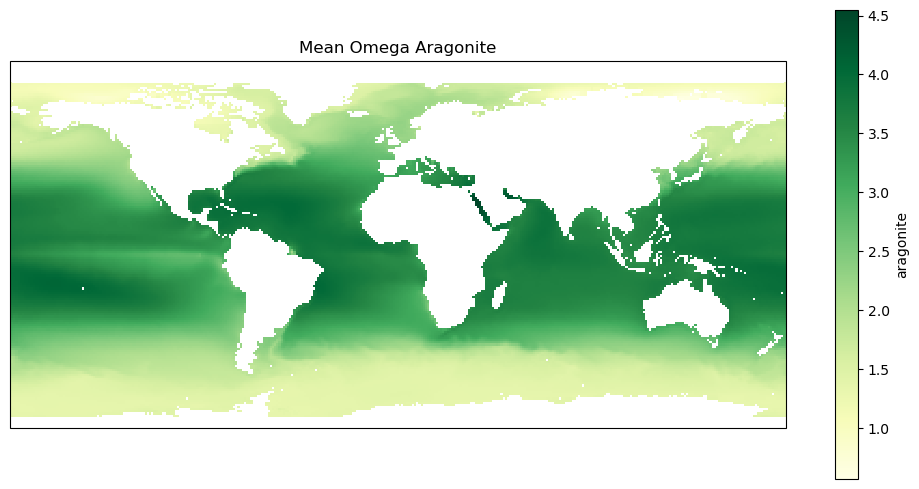

In [8]:
# Création de la figure
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Affichage de la carte
im = (acidity.mean(dim='time', skipna=True)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGn',         # Choix du colormap ici (ex : 'viridis', 'plasma', 'cividis', 'Spectral')
    cbar_kwargs={'label': 'aragonite'}
)

# Ajout de côtes et titres
#ax.coastlines()
ax.set_title('Mean Omega Aragonite')
plt.tight_layout()
plt.show()


## CMEMS

In [5]:
# Load T, NPP 
path="/data/rd_exchange/sroyer/SEAPOPYM/Sophie_GLOBAL_MULTIYEAR_BGC_001_033.zarr"
ds_forcings=xr.open_zarr(path)
ds_forcings = ds_forcings.chunk({
    "time": -1,
    "latitude": 10,
    "longitude": 10,
})
# Variables 
ds_T=ds_forcings['temperature'].sel(depth=0) # epipelagic layer
ds_npp=ds_forcings['primary_production']


# apply mask
with xr.set_options(keep_attrs=True):
    # temperature
    T_masked = ds_T.where(mask_ocean)
    # primary production 
    npp_masked = ds_npp.where(mask_ocean)

temperature = T_masked
temperature.attrs["units"] = "degrees Celsius"
temperature.name = None
temperature["time"].attrs["standard_name"]="time"
temperature["time"].attrs["axis"]="T"
temperature["latitude"].attrs["standard_name"]="latitude"
temperature["latitude"].attrs["axis"]="Y"
temperature["longitude"].attrs["standard_name"]="longitude"
temperature["longitude"].attrs["axis"]="X"
temperature=temperature.assign_coords({"time": temperature.time.dt.floor("D")})

primary_production=npp_masked
primary_production.attrs["units"] = "mg m-2 day-1"
primary_production.name=None
primary_production["time"].attrs["standard_name"]="time"
primary_production["time"].attrs["axis"]="T"
primary_production["latitude"].attrs["standard_name"]="latitude"
primary_production["latitude"].attrs["axis"]="Y"
primary_production["longitude"].attrs["standard_name"]="longitude"
primary_production["longitude"].attrs["axis"]="X"
primary_production=primary_production.assign_coords({"time": primary_production.time.dt.floor("D")})


In [6]:
ds_forcings['mask'].sel(latitude=slice(-80,80))

<xarray.DataArray 'mask' (latitude: 161, longitude: 360)> Size: 58kB
dask.array<getitem, shape=(161, 360), dtype=bool, chunksize=(10, 10), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) int16 322B -80 -79 -78 -77 -76 -75 ... 76 77 78 79 80
  * longitude  (longitude) int16 720B -180 -179 -178 -177 ... 176 177 178 179

### NPP

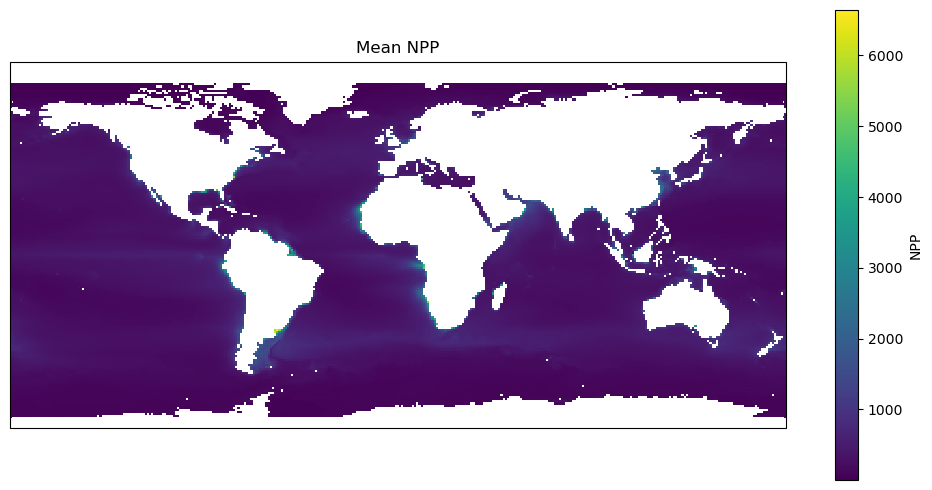

In [14]:
# Création de la figure
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Affichage de la carte
im = (primary_production.mean(dim='time', skipna=True)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='viridis',         # Choix du colormap ici (ex : 'viridis', 'plasma', 'cividis', 'Spectral')
    cbar_kwargs={'label': 'NPP'}
)

# Ajout de côtes et titres
#ax.coastlines()
ax.set_title('Mean NPP')
plt.tight_layout()
plt.show()


### Temperature

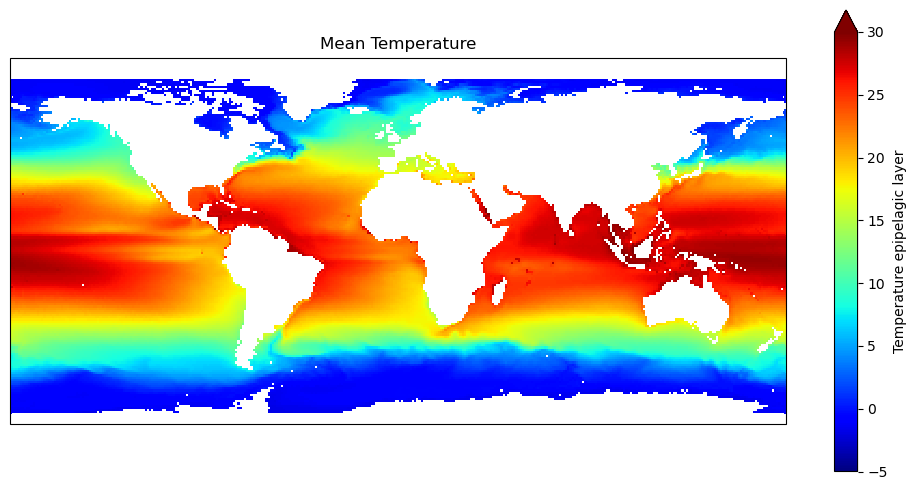

In [18]:
# Création de la figure
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Affichage de la carte
im = (temperature.mean(dim='time', skipna=True)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='jet',
    vmin=-5,
    vmax=30,      
    cbar_kwargs={'label': 'Temperature epipelagic layer'}
)

# Ajout de côtes et titres
#ax.coastlines()
ax.set_title('Mean Temperature')
plt.tight_layout()
plt.show()


/tmp/ipykernel_246588/3861012444.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # laisser de la place à la colorbar


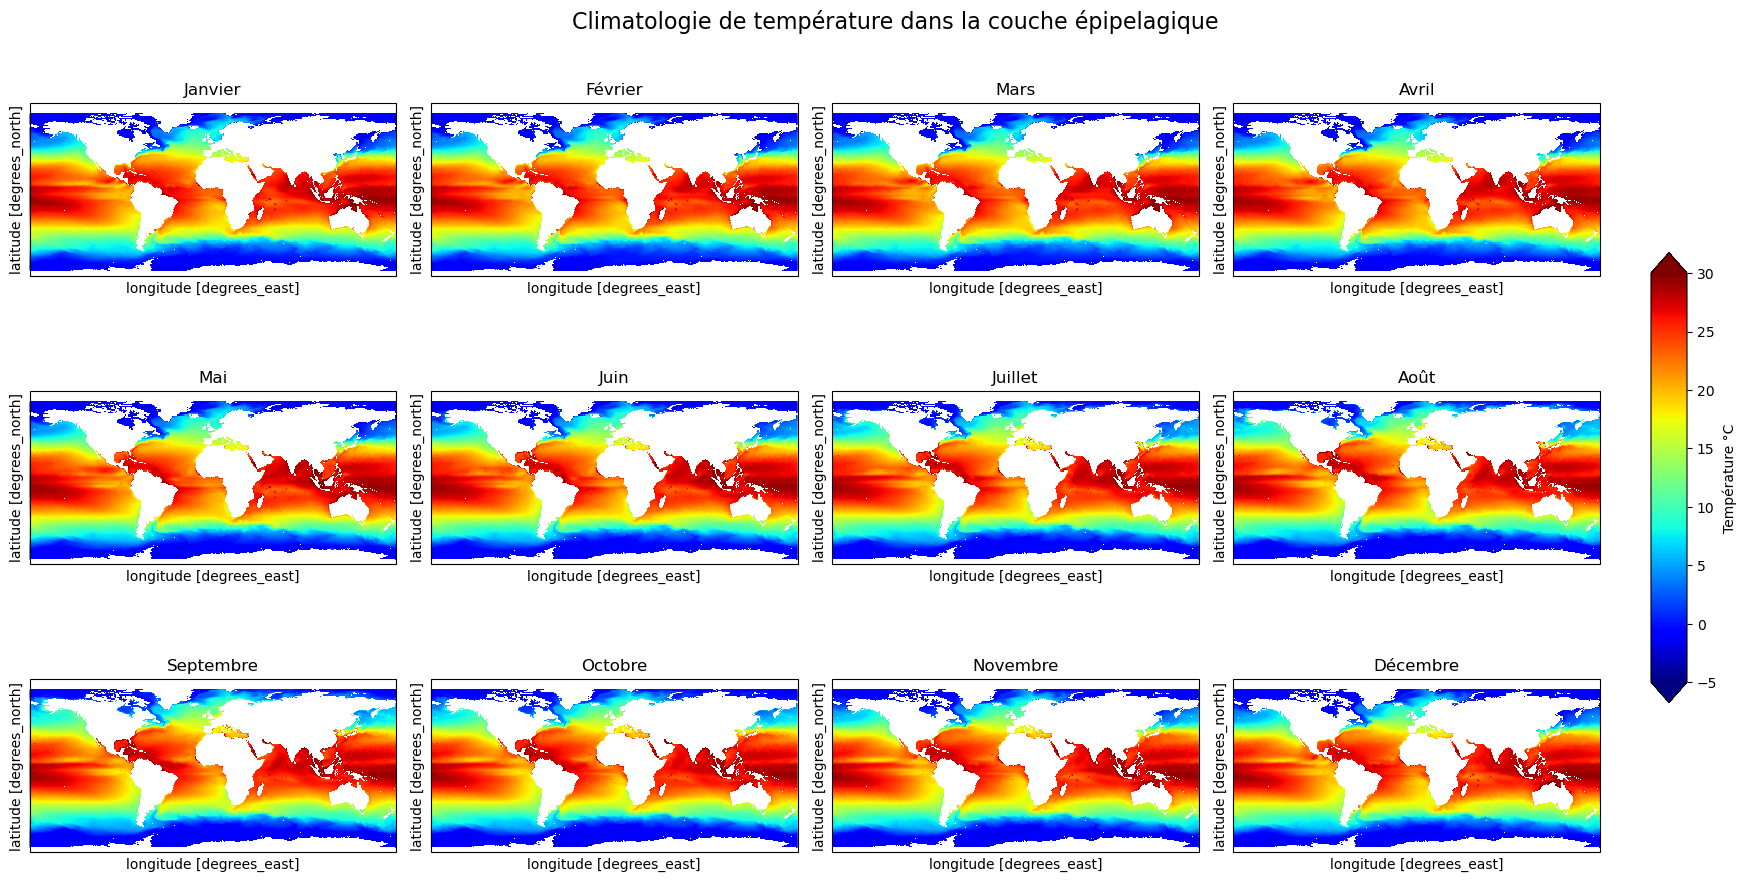

In [17]:
# Figure et axes
fig, axes = plt.subplots(nrows=3, ncols=4, figsize = (18, 9),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes for easy looping
axes = axes.flatten()
months=['Janvier','Février','Mars', 'Avril','Mai' ,'Juin',
        'Juillet','Août', 'Septembre' ,'Octobre','Novembre','Décembre']
# Plot each month
for i in range(12):
    ax = axes[i]
    im = temperature.groupby('time.month').mean(dim='time', skipna=True).sel(month=i+1).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='jet',
        vmax=30,
        vmin=-5,
        add_colorbar=False,
    )
    ax.set_title(f"{months[i]}")
    #ax.coastlines()
    ax.set_xticks([])
    ax.set_yticks([])

# Ajouter une barre de couleur commune
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Température °C',extend="both")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # laisser de la place à la colorbar
plt.suptitle("Climatologie de température dans la couche épipelagique", fontsize=16, y=1.02)
plt.show()
